<a href="https://colab.research.google.com/github/jankotschy/Applied-AI-in-Transportation/blob/main/Assignment_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Revealing representative "typical" day-types using traffic data observation and clustering

Clustering is a way of letting the data tell us its own story. Instead of assuming traffic always follows the same daily rhythm, we will use clustering to discover “typical day-types”: weekdays, weekends, holidays, incidents, straight from sensor observations. By the end of this exercise, you will learn how to prepare temporal data for clustering, explore it and reflect on what the patterns might mean for managing roads in practice.

Objective: find, evaluate and choose a clustering of daily time-series (day-profiles), and show how that clustering helps a simple prediction task.

what this notebook does:

Data loading & Exploratory Data Analysis (visualize raw day profiles).
Preprocessing
Baseline experiments (k-means), time-series alternatives (k-Shape or DTW), and at least one density/soft model (GMM/DBSCAN).
Internal evaluation (silhouette, Calinski-Harabasz, Davies-Bouldin) + stability checks.
Time-aware external evaluation using the centroid-based historical-mean predictor (RMSE, MAPE).
Interpretation: centroids, representative days and weekday distribution
Glossary
day-profile / day-matrix: one row = one day; columns = 5-minute buckets.
centroid historical-mean predictor: for each cluster, predict a day by using the cluster centroid (or average of historical days assigned to that cluster).

## Data preparation

In [52]:
import pandas as pd
import numpy as np
# Load the training dataset (2021). Place the CSV in the same folder as this notebook,
# or update the path below.
data_df = pd.read_csv("/content/dataset_exercise_5_clustering_highway_traffic (1).csv", sep=";")
data_df

,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52
...,...,...,...,...,...,...,...
104838,"E4S 56,780",20211231,23:35:00,23:40:00,283,19.58,115
104839,"E4S 56,780",20211231,23:40:00,23:45:00,284,19.47,87
104840,"E4S 56,780",20211231,23:45:00,23:50:00,285,19.77,130
104841,"E4S 56,780",20211231,23:50:00,23:55:00,286,18.79,129


The provided dataset contains 5-minute observations on one highway microwave sensor and needs to be in a format ready for clustering. Clustering doesn’t work on raw tables, it needs a structured representation. In this section, we will take the raw sensor data and reformat it so that each entire day becomes a single data vector. This makes it possible to compare whole days against each other.

Here’s the logic: a day is 24 hours long, and with 5-minute measurements that means 288 data points. If we line these up in order, we can represent each day as a 288-dimensional vector: one row per day, one column per time slot. Later, clustering will group these day-vectors into families of “similar days.” This is "giving every day its own fingerprint."

In [53]:
# Sort the DataFrame 'data_df' by columns "Date" and "Interval_5"
data_df.sort_values(["Date", "Interval_5"])

# Extract unique dates from the sorted DataFrame
days = np.unique(data_df[['Date']].values.ravel())
# Calculate the total number of unique days
ndays = len(days)

# Group the DataFrame 'data_df' by the "Date" column
day_subsets_df = data_df.groupby("Date")

# Define the total number of 5-minute intervals in a day
nintvals = 288

# Create a matrix 'vectorized_day_dataset' filled with NaN values
vectorized_day_dataset = np.zeros((ndays, nintvals))
vectorized_day_dataset.fill(np.nan)

# Loop through each unique day
for i in range(0, ndays):
    # Get the DataFrame corresponding to the current day
    df_t = day_subsets_df.get_group(days[i])

    # Loop through each row in the current day's DataFrame
    for j in range(len(df_t)):
        # Get the current day's DataFrame
        df_t = day_subsets_df.get_group(days[i])

        # Extract the "Interval_5" and "flow" values and populate 'vectorized_day_dataset'
        vectorized_day_dataset[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

# Print the resulting 'vectorized_day_dataset'
print(vectorized_day_dataset)

[[ 39.  18.  26. ...  32.  39.  34.]
 [ 30.  32.  27. ...  44.  41.  39.]
 [ 36.  44.  52. ...  50.  45.  23.]
 ...
 [ 20.  34.  31. ...  38.  42.  36.]
 [ 36.  40.  25. ...  38.  56.  35.]
 [ 33.  32.  34. ... 130. 129. 117.]]


Recap of the steps the code did:

STEP 1:We sorted the data to guarantee chronological order.
STEP 2:We pulled out all unique days, so we know how many daily profiles we need.
STEP 3:We fixed the number of time slots (288) so every day has the same length.
STEP 4:We built a big empty matrix, one row per day, one column per 5-minute slot.
STEP 5:Finally, we filled this matrix: for each day, we inserted the flow values into the right time slots.
The result: a clean “day × time” dataset ready for clustering. From here on, each row can be treated like a single point in a 288-dimensional space.

Note that if you plan to reveal network-wide day-types (more sensors), this day vector can be ordered vector of SENSORS * TIME-INTERVALS.

# Part 1: Data exploration

# 1.1 : Missing values and outliers

Before we trust this matrix, we need to explore it. Clustering algorithms are very sensitive to missing values and outliers: a single "bad day" can distort entire clusters. Let’s check for gaps and anomalies before we hand the data to the clustering algorithm.

In [54]:

print('number of nans',np.sum(np.isnan(vectorized_day_dataset)))
print('rate of nans',np.sum(np.isnan(vectorized_day_dataset))/(ndays*nintvals))

number of nans 277
rate of nans 0.0026350837138508373


The quick check shows only 277 missing entries, which is just 0.26% of the data. That is very low but missingness is rarely random. In traffic data, it could mean times when no vehicles were detected (night hours) or moments when sensors temporarily failed. Spotting where/when these gaps happen helps us decide whether to ignore them, fill them in or treat them as a signal themselves.

(288,)


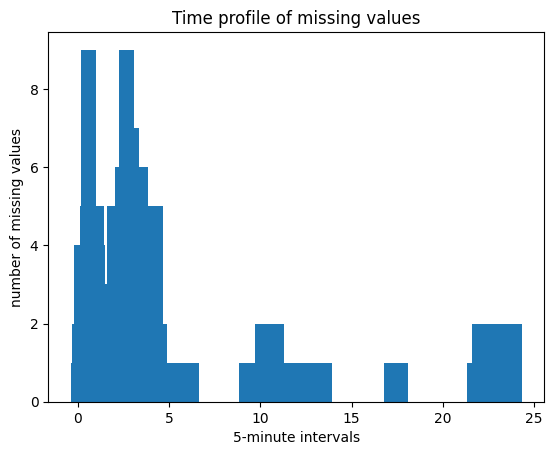

In [55]:
nans_per_time = np.sum(np.isnan(vectorized_day_dataset),0)
print(nans_per_time.shape)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
# Create an array 'x_axis' representing the 5-minute intervals
x_axis = np.arange(0, nintvals, 1, dtype=int)
# Initialize an empty list 'x_axis_hours' to store time values in hours
x_axis_hours = []
# Convert interval indices to hours and append them to 'x_axis_hours'
for i in range(0, len(x_axis)):
  x_axis_hours.append(float(x_axis[i]*5)/60)
ax.bar(x_axis_hours,height=nans_per_time)


ax.set_ylabel('number of missing values')
ax.set_xlabel('5-minute intervals')
ax.set_title('Time profile of missing values')

plt.show()

Are these missing values associated with just a few days?

In [56]:
nans_per_day = np.sum(np.isnan(vectorized_day_dataset),1)
print('number of days with missing value',np.size(np.where(nans_per_day > 0),1))

number of days with missing value 28


# Part 1.2 : Daily profile of flow dynamic

Visualizing traffic flow across time of day reveals the heartbeat of the system. What does the data look like? What is the traffic pattern? You should expect sharp rises around commuting hours and dips overnight. These daily profiles are important because clustering algorithms will later decide “similarity” based on the shapes of these curves. When you see peaks or irregular bumps, think about what real world behaviors they correspond to: work commute, evening leisure, freight transport.

Below is the script that can help you visualize all days where overlapping transparencies highlight some patterns. The black line is the average yearly flow for a time interval.

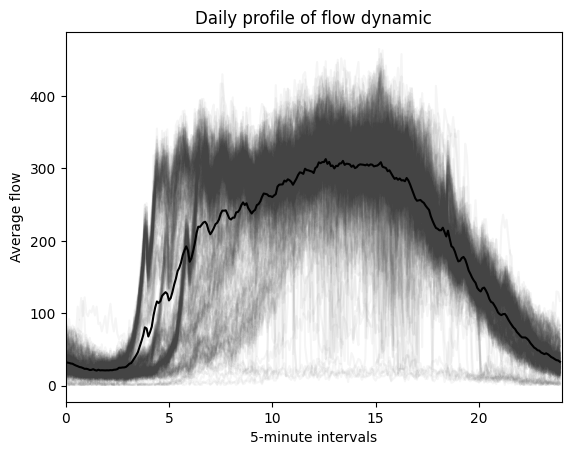

In [57]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()# a convenient way to create a new figure and a set of subplots.
ax.plot(np.array([x_axis_hours,]*ndays).transpose(),vectorized_day_dataset.transpose(),color='#444444',alpha=0.05)
# Above line plots the dataset with specified color and transparency.
ax.plot(x_axis_hours,np.transpose(np.nanmean(vectorized_day_dataset,0)),color='black')
# Above line plots the average of the dataset in black color.

ax.set_ylabel('Average flow')
ax.set_xlabel('5-minute intervals')
plt.xlim(0,24)
ax.set_title('Daily profile of flow dynamic')

plt.show()

Boxplots compress the daily data into distributions for each 5-minute slot. They tell us not only the average but also the spread and the outliers. Below is the code to visualize these boxplots

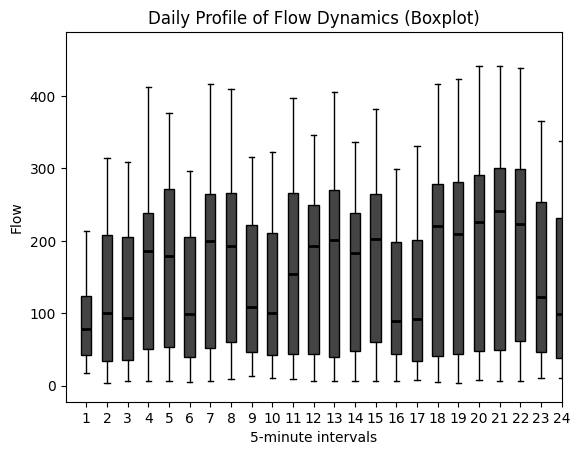

In [58]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()  # This line is a convenient way to create a new figure and a set of subplots.

# Create a boxplot for the dataset
boxplot = ax.boxplot(vectorized_day_dataset.T, patch_artist=True)

# Customize the boxplot appearance
for patch in boxplot['boxes']:
    patch.set_facecolor('#444444')  # Set the box color to gray
for median in boxplot['medians']:
    median.set(color='black', linewidth=2)  # Set median line color to black

# Set the y-axis label
ax.set_ylabel('Flow')

# Set the x-axis label
ax.set_xlabel('5-minute intervals')

# Set the x-axis limits to be between 0 and 24
plt.xlim(0, 24)

# Set the title of the plot
ax.set_title('Daily Profile of Flow Dynamics (Boxplot)')

# Display the plot
plt.show()

Notice whether morning peaks are tight (predictable) or wide (variable). Wide distributions could mean more “noise” for clustering, the algorithm will find it harder to decide what is typical for that time slot.

By averaging days into weekdays vs. weekends, we test a very human hypothesis: “Mondays don’t look like Sundays.” Do the curves confirm it? This step bridges human intuition (calendar categories) with machine learning exploration (clustering). Later, we’ll see whether the algorithm rediscovers these patterns or finds something subtler, like holiday effects.

In [59]:
import datetime

# Create an array 'day_of_week' to store the day of the week for each unique date
day_of_week = np.zeros((ndays))

# Loop through each unique date
for i in range(0, ndays):
    # Parse the current date from a string to a datetime object
    day_dt = datetime.datetime.strptime(str(days[i]), '%Y%m%d')

    # Get the day of the week (1 for Monday, 2 for Tuesday, ..., 7 for Sunday)
    day_of_week[i] = day_dt.isoweekday()

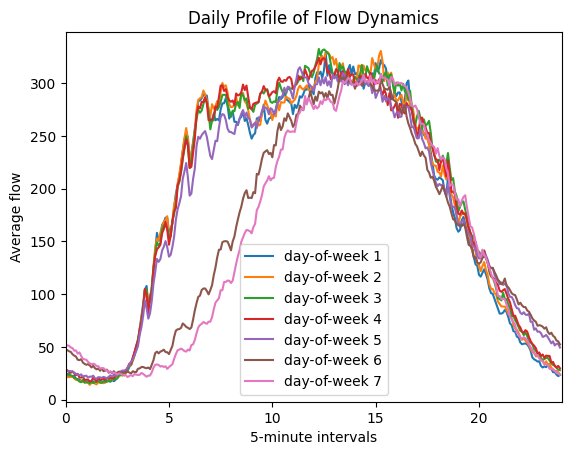

In [60]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()

# Iterate through each day of the week (from 1 to 7)
for i in range(1, 8):
    # Find the indices of days that correspond to the current day of the week
    day_of_week_index_t = np.where(day_of_week == i)

    # Calculate the number of days that match the current day of the week
    ndays_t = np.size(day_of_week_index_t[0])

    # Plot the average flow for the current day of the week
    ax.plot(x_axis_hours,
            np.nanmean(vectorized_day_dataset[day_of_week_index_t[0], :].transpose(), 1),
            label='day-of-week ' + str(i))
    # This line plots the average flow for the current day of the week.
    # 'np.nanmean()' calculates the mean while handling NaN values.

# Set the y-axis label
ax.set_ylabel('Average flow')

# Set the x-axis label
ax.set_xlabel('5-minute intervals')

# Set the x-axis limits to be between 0 and 24
plt.xlim(0, 24)

# Set the title of the plot
ax.set_title('Daily Profile of Flow Dynamics')

# Add a legend indicating the day of the week
ax.legend()

# Display the plot
plt.show()

The day's index is from 1 - 7, where 1 is Monday. To our expectations, we can see the difference between weekdays and weekends. So far, we’ve established that traffic days differ in systematic ways: weekday/weekend, time-of-day peaks, occasional anomalies. Clustering will now formalize these differences into groups. The goal is to let the algorithm discover with patterns that we might not have thought to test manually. This we explore with clustering in the next part of the exercise.

# Part 2: Clustering

In the previous section, we explored our data and prepared it for analysis. Now, we reach the core of our task: clustering. Our goal is to group similar days together to discover common daily traffic patterns, or "day-types."

We face a fundamental question in clustering: how many clusters (k) are there? There is no single "correct" answer; it depends on the story the data tells and our analytical goals. Once we have our clusters, we will visualize the resulting day-types (cluster centroids) and analyze their characteristics to understand what each "typical day" represents ( a weekday rush hour pattern, a quiet weekend pattern, incidents)

## Clustering

Using clustering methods in scikit-learn is relatively simple, as shown below. With one line of code, you can get some clusters. However, this will need some work to search for representative clusters. This is the first step to pattern exploration.

In [61]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

#clusters = KMeans(n_clusters=10, random_state=0, n_init="auto").fit(vectorized_day_dataset)


As you can see k-means clustering method can not handle missing values, so you have choices: impute data or remove them. We will just remove all days that have missing observations. Fewer days would be removed if we restrict the clustering to a particular day-time period, 06:00 - 22:00:00. Below, we prepare a new dataset without missing values and update the list of days for later visualization purposes.

In [62]:
n_clusters = 10
clusters = None
#print(np.where(nans_per_day > 0)[0])

# Days to manually exclude in addition to days with missing values
days_to_exclude = ['20210704', '20210805', '20211002', '20211210']
manual_exclude_mask = np.isin(days, np.array(days_to_exclude, dtype=days.dtype))

vectorized_day_dataset_no_nans = vectorized_day_dataset[np.where((nans_per_day == 0) & (~manual_exclude_mask))[0],:]
days_not_nans = days[np.where((nans_per_day == 0) & (~manual_exclude_mask))[0]]

# BELOW lines enables you to comment in and out clustering method you want to use note that GMM have different ouput and thus labels are extracted differently
clusters = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(vectorized_day_dataset_no_nans) # check the parameters at https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# clusters = AgglomerativeClustering(n_clusters=n_clusters,metric='euclidean', linkage='ward').fit(vectorized_day_dataset_no_nans) # check the parameters at https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html
# clusters = DBSCAN(eps=500, min_samples = 2).fit(vectorized_day_dataset_no_nans) # check the parameters at https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

if clusters is not None:
  cluster_labels = clusters.labels_

#cluster_labels = GaussianMixture(n_components=n_clusters).fit(vectorized_day_dataset_no_nans).predict(vectorized_day_dataset_no_nans) #check the parameters at  https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_init.html#sphx-glr-auto-examples-mixture-plot-gmm-init-py


print(cluster_labels)

[5 5 5 6 9 5 6 6 5 5 6 6 6 6 6 5 5 6 6 4 4 4 1 5 6 6 6 6 5 5 6 6 6 6 6 5 5
 6 6 6 6 6 1 1 6 4 4 4 1 1 4 4 4 4 1 1 4 4 6 4 6 1 1 4 6 4 6 4 1 1 4 4 4 4
 4 1 1 4 4 6 4 4 1 4 4 1 5 1 5 6 4 4 4 1 1 4 4 4 4 4 1 1 4 4 4 4 4 1 1 4 4
 4 4 4 1 9 8 8 8 8 3 2 9 8 8 3 2 0 2 9 8 8 2 9 8 8 3 8 3 9 9 8 3 3 3 3 2 9
 8 8 3 3 3 2 9 8 3 3 8 0 2 9 8 3 3 3 2 5 9 3 0 8 0 0 2 0 3 0 2 2 0 0 0 0 0
 2 2 0 0 0 0 0 2 2 0 0 2 9 0 0 0 9 9 0 0 0 8 3 2 9 8 8 3 3 3 9 9 8 8 8 3 3
 9 9 8 8 8 8 3 9 8 9 9 8 8 3 8 3 9 9 8 8 8 8 9 9 8 8 8 8 8 8 8 8 9 9 8 8 8
 8 3 2 9 8 8 8 3 3 9 9 3 8 8 8 9 9 7 7 7 7 1 1 7 7 7 0 9 1 7 7 7 7 7 9 1 7
 7 7 7 7 9 1 7 7 7 7 7 1 1 7 0 7 1 1 7 7 7 7 7 1 1 7 7 7 2 5 5 5 2 9 9 9 5]


## Visualizaiton of representative day-type patterns

### Special plots for visualizing day-type patterns

the results of clusterings are assignments to the clusters, this can be hard to read and make conclusions about it, so visualization of data in right way is of high importance. Below is a script gives you set of libraries for calendar and centroid visualizaiton.

***Note: The below script you do not have to understand. Consider it as an external library that will plot for you, just like a histogram plot, for which you also do not know the exact implementation. Anyway, this course does not focus on information visualization.***

In [63]:

from dateutil.relativedelta import relativedelta
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.patches import Patch
from matplotlib import colors

def assign_colors(n_clusters, days, assigments):

    days_colors = []
    color_to_cluster = []
    style_to_cluster = []
    weekend_colors = ['#67001f','#d6604d','#fdae61','#f46d43','#d53e4f','#9e0142','#f768a1','#f1c232']#,'#fe9929','#cc4c02','#e31a1c','#737373','#bdbdbd','#252525','#bcbddc']
#    weekend_school_colors = ['#c2a5cf','#f1b6da','#8e0152','#c51b7d','#de77ae','#ae017e','#fcc5c0','#e31a1c','#737373','#bdbdbd']
#    bank_holidays_colors = ['#543005','#dfc27d','#bf812d','#8c510a']
    mixed_colors = ['#4d4d4d','#35978f','#bababa','#878787']
    weekday_colors = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#cab2d6','#6a3d9a','#b15928','#8dd3c7','#bebada','#fb8072','#b3de69','#bc80bd','#fccde5','#ccebc5','#35978f','#80cdc1']

    cluster_id_weekdays_share = []
    cluster_id_weekend_share = []
    cluster_id_all_days = []

    for i in range(0,n_clusters):
        color_to_cluster.append(None)
        style_to_cluster.append(None)
        cluster_id_weekdays_share.append(0)
        cluster_id_weekend_share.append(0)
        cluster_id_all_days.append(0)

    for i in range(0,len(days)):
        #print(i,assigments[i],len(assigments),len(cluster_id_all_days))
        if assigments[i] is not None:
            cluster_id_all_days[assigments[i]] += 1
            if '-' in str(days[i]):
                pomT = datetime.datetime.strptime(str(days[i]),'%Y-%m-%d')
            else:
                pomT = datetime.datetime.strptime(str(days[i]),'%Y%m%d')

            if int(pomT.weekday()) < 5:
                cluster_id_weekdays_share[assigments[i]] += 1
            else:
                cluster_id_weekend_share[assigments[i]] += 1

    print('cluster_id_weekdays_share',cluster_id_weekdays_share)
    print('cluster_id_weekend_share',cluster_id_weekend_share)
    for i in range(0,len(days)):
        if assigments[i] is not None:
            cluster_idx = assigments[i]
            if '-' in str(days[i]):
                pomT = datetime.datetime.strptime(str(days[i]),'%Y-%m-%d')
            else:
                pomT = datetime.datetime.strptime(str(days[i]),'%Y%m%d')
            if color_to_cluster[assigments[i]] is None:
                if cluster_id_weekend_share[cluster_idx] / float(cluster_id_all_days[cluster_idx]) > 0.6:
                        color_to_cluster[assigments[i]] = weekend_colors.pop()
                        style_to_cluster[assigments[i]] = ':'
                elif cluster_id_weekdays_share[cluster_idx] / float(cluster_id_all_days[cluster_idx]) > 0.6:
                        color_to_cluster[assigments[i]] = weekday_colors.pop(0)
                        style_to_cluster[assigments[i]] = '-'
                else:
                    color_to_cluster[assigments[i]] = mixed_colors.pop()
                    style_to_cluster[assigments[i]] = ':'

            days_colors.append(color_to_cluster[assigments[i]])
        else:
            days_colors.append(None)

    return days_colors,color_to_cluster,style_to_cluster


def calmap(ax, year, data, days, assigments, n_clusters,days_colors,color_to_cluster,
           limit_graphics=False):

    ax.tick_params('x', length=0, labelsize="medium", which='major')
    ax.tick_params('y', length=0, labelsize="x-small", which='major')

    # Month borders

    xticks, labels = [], []
    start = datetime.datetime(year,1,1).weekday()

    for month in range(1,13):

        first = datetime.datetime(year, month, 1)
        last = first + relativedelta(months=1, days=-1)

        y0 = first.weekday()
        y1 = last.weekday()
        x0 = (int(first.strftime("%j"))+start-1)//7
        x1 = (int(last.strftime("%j"))+start-1)//7

        P = [ (x0,   y0), (x0,    7),  (x1,   7),
              (x1,   y1+1), (x1+1,  y1+1), (x1+1, 0),
              (x0+1,  0), (x0+1,  y0) ]

        xticks.append(x0 +(x1-x0+1)/2)
        labels.append(first.strftime("%b"))
        poly = Polygon(P, edgecolor="black", facecolor="None",

                       linewidth=1, zorder=20, clip_on=False)

        ax.add_artist(poly)

    line = Line2D([0,53],[5,5],linewidth=1, zorder = 20,color="black",linestyle='dashed')
    ax.add_artist(line)

    if not limit_graphics:
        ax.set_xticks(xticks)
        ax.set_xticklabels(labels)
        ax.set_yticks(0.5 + np.arange(7))
        ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
        ax.set_title("{}".format(year), weight="semibold")
    else:
        plt.tick_params(
            axis='x',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            bottom=False,      # ticks along the bottom edge are off
            top=False,         # ticks along the top edge are off
            labelbottom=False)
        plt.tick_params(
            axis='y',          # changes apply to the x-axis
            which='both',      # both major and minor ticks are affected
            left=False,      # ticks along the bottom edge are off
            right=False,         # ticks along the top edge are off
            labelleft=False)

    # Clearing first and last day from the data
    valid = datetime.datetime(year, 1, 1).weekday()
    data[:valid,0] = np.nan
    valid = datetime.datetime(year, 12, 31).weekday()
    # data[:,x1+1:] = np.nan
    data[valid+1:,x1] = np.nan

    for i in range(0,len(days)):
        if '-' in str(days[i]):
            pomT = datetime.datetime.strptime(str(days[i]),'%Y-%m-%d')
        else:
            pomT = datetime.datetime.strptime(str(days[i]),'%Y%m%d')
        week_number = int(pomT.strftime("%W"))
        day_of_week = int(pomT.weekday())
        data[day_of_week,week_number] = assigments[i]


    act_date = datetime.datetime(year,1,1)
    while (act_date.year == year):

        week_number = int(act_date.strftime("%W"))
        day_of_week = int(act_date.weekday())
        doy_id = act_date.timetuple().tm_yday
        if doy_id<5 and week_number > 53:
            week_number = 0

        act_date = act_date + datetime.timedelta(days=1)

    #pomT = datetime.datetime.strptime('2017-01-01','%Y-%m-%d')
    #week_number = int(pomT.strftime("%V"))
    #day_of_week = int(pomT.weekday())
    #print(week_number,day_of_week)
    #doy_id = pomT.timetuple().tm_yday
    #if doy_id<5 and week_number > 0:
    #    week_number = 0
    #data[day_of_week,week_number] = len(clusters)+10

    # Showing data
    cmap = plt.cm.spring  # Can be any colormap that you want after the cm
    cmap.set_bad(color='white')

    #ax.imshow(data, extent=[0,53,0,7], zorder=10, vmin=0, vmax=len(clusters)+10,
    #          cmap=cmap, origin="lower", alpha=.75)

    cmap = colors.ListedColormap(color_to_cluster)
    bounds=[-0.1]
    step = 1
    for i in range(0,n_clusters):
        bounds.append(i-0.1+step)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    #print(color_to_cluster)
   #print(bounds)
    #print(norm)

    #print(color_to_cluster)
    #print(bounds)
    #print(cmap)
    #exit(0)

    ax.imshow(data, extent=[0,53,0,7], zorder=10, interpolation='nearest', origin='lower',cmap=cmap, norm=norm)

def make_calendar_visualization_figure(days,assigments,n_clusters,years,days_colors,color_to_cluster,
                                       save_figure: str = None, show_figure:bool = True, limit_graphics = False):

    fig = plt.figure(figsize=(8,1.5*len(years)), dpi=100)
    X = np.linspace(-1,1, 53*7)

    for i, obj in enumerate(years):

        pom_s = str(len(years))+'1'+str(i+1)
        print(pom_s)

        ax = plt.subplot(int(pom_s), xlim=[0, 53], ylim=[0, 7], frameon=False, aspect=1)
        I = 1.2 - np.cos(X.ravel()) + np.random.normal(0,.2, X.size)
        I = I.reshape(53,7).T
        I.fill(np.nan)
        calmap(ax, int(obj), I.reshape(53,7).T, days, assigments, n_clusters,days_colors,color_to_cluster, limit_graphics)

    #   ax = plt.subplot(212, xlim=[0,53], ylim=[0,7], frameon=False, aspect=1)
    #  I = 1.1 - np.cos(X.ravel()) + np.random.normal(0,.2, X.size)
    #   calmap(ax, 2018, I.reshape(53,7).T)

    #ax = plt.subplot(313, xlim=[0,53], ylim=[0,7], frameon=False, aspect=1)
    #I = 1.0 - np.cos(X.ravel()) + np.random.normal(0,.2, X.size)
    #calmap(ax, 2019, I.reshape(53,7).T)
    if save_figure:
        plt.savefig(save_figure)

    if show_figure or save_figure is None:
        plt.tight_layout()
        plt.show()


def make_figure_centroids(x,y,color_to_cluster,style_to_cluster,cluster_ids,minY = None,maxY = None,
                          save_figure: str = None, show_figure:bool = True):

    #print(color_to_cluster)
    fig = plt.figure(figsize=(8,3))
    ax = fig.add_subplot(111)
    for i in range(0,len(x)):
        #print(i,color_to_cluster[i],style_to_cluster[i])
        #print(y[i])
        ax.plot(x[i],y[i],style_to_cluster[i], color=color_to_cluster[i], label=str(cluster_ids[i]))
    ax.set_xlabel('Time of day')
    ax.set_ylabel('Flow')
    if minY is not None and maxY is not None:
        ax.set_ylim([minY, maxY])
    plt.legend()

    if save_figure:
        plt.savefig(save_figure)

    if show_figure or save_figure is None:
        plt.tight_layout()
        plt.show()



### Visualization

#### Calendar visualization

Using the above functions for visualization, the representative day-type clusters can be seen in a calendar form in order to enable us by-eye analysis to make sense of these clusters. Do cluster labels form temporally coherent patterns when viewed across a calendar? In particular, do weekends, holidays or seasonal cycles explain cluster placement? Note that white cells are removed days because of missing observations

cluster_id_weekdays_share [27, 1, 4, 31, 45, 5, 31, 32, 54, 4]
cluster_id_weekend_share [0, 33, 16, 0, 0, 15, 0, 0, 0, 35]
111


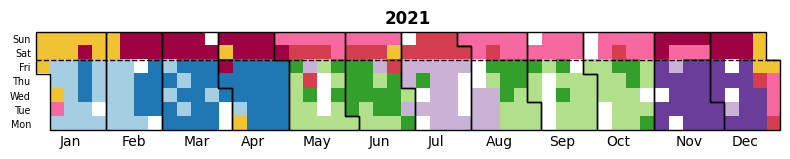

In [64]:
# Calculate the number of clusters by finding unique values in 'cluster_labels'
n_clusters_t = len(np.unique(cluster_labels))

# Assign colors to days based on clusters
days_colors, color_to_cluster, style_to_cluster = assign_colors(n_clusters_t, days_not_nans, cluster_labels)
# The function 'assign_colors' is used to determine colors and styles for visualization.

# Create a calendar visualization figure
make_calendar_visualization_figure(days_not_nans, cluster_labels, n_clusters_t, [2021], days_colors,
                                   color_to_cluster, save_figure=None)
# This function 'make_calendar_visualization_figure' is used to generate a visualization based on the provided data and parameters.
# 'days_not_nans' are the days, 'cluster_labels' are the cluster labels, 'n_clusters_t' is the number of clusters,
# '[2021]' represents the year, 'days_colors' represent the assigned colors for each day, 'color_to_cluster' maps colors to clusters,
# and 'save_figure' is an optional parameter to save the generated figure (can be None if not saving).

#### Day-time profile of centroids

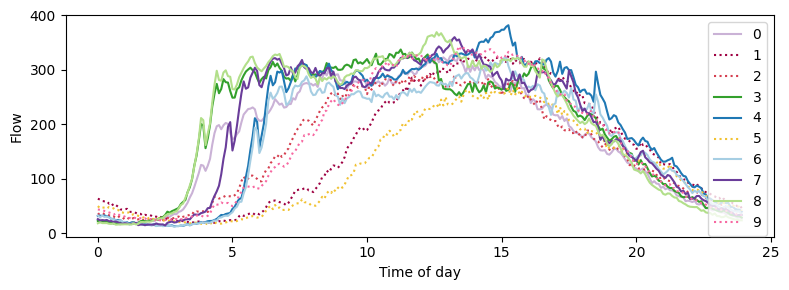

In [65]:
# Initialize empty lists to store centroid data
centroids_xx = []  # x-axis values for centroids
centroids_yy_daytypes = []  # y-axis values for centroids, grouped by day types
cluster_ids = []  # Cluster IDs

# Iterate through each cluster
for i in range(0, n_clusters_t):
    # Store the x-axis values for centroids (hours of the day)
    centroids_xx.append(x_axis_hours)

    # Calculate the y-axis values for centroids (average flow for each 5-minute interval)
    centroid_yy = list(np.nanmean(vectorized_day_dataset_no_nans[np.where(cluster_labels == i)[0], :], 0).transpose())
    centroids_yy_daytypes.append(centroid_yy)

    # Store the cluster ID
    cluster_ids.append(i)

# Generate a figure displaying the centroids
make_figure_centroids(centroids_xx, centroids_yy_daytypes, color_to_cluster, style_to_cluster, cluster_ids)
# The function 'make_figure_centroids' is used to create a visualization of the centroids,
# with the provided data and parameters.

Next, we can explore the day-type profiles. Centroids compress intra-day variability into an average, smoothness and within-cluster spread must be inspected together. A sharp, narrow peak in a centroid with small within-cluster spread implies a reliable, repeatable event. A noisy centroid suggests heterogeneity or too few members.

As you can see with first shot using k-means we can see much more day-type patterns as we may expect, it even enable to identify potential outliers/incident like cluster 7.

# Part 3: Assignment - clustering evaluation


## 3.1 Helper functions

To avoid writing near-identical code for k-means / agglomerative / GMM / DBSCAN over and over, we wrap
fitting, centroid extraction, and the short-term prediction evaluation (introduced above) into small,
reusable functions.

In [66]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score
import sklearn.metrics.pairwise as dis_lib

def fit_clustering(method, Xd, **params):
    if method == "kmeans":
        model = KMeans(n_clusters=params["k"], random_state=0, n_init="auto").fit(Xd)
        return model.labels_
    if method == "agglomerative":
        model = AgglomerativeClustering(n_clusters=params["k"], metric="euclidean",
                                         linkage=params.get("linkage", "ward")).fit(Xd)
        return model.labels_
    if method == "dbscan":
        model = DBSCAN(eps=params["eps"], min_samples=params.get("min_samples", 3)).fit(Xd)
        return model.labels_
    if method == "gmm":
        model = GaussianMixture(n_components=params["k"], covariance_type=params.get("cov", "diag"),
                                 random_state=0).fit(Xd)
        return model.predict(Xd)
    raise ValueError(f"unknown method {method}")


def internal_scores(Xd, labels):
    mask = labels != -1
    Xd_eff, labels_eff = Xd[mask], labels[mask]
    n_clusters_found = len(np.unique(labels_eff))
    if n_clusters_found < 2 or n_clusters_found >= len(labels_eff) - 1:
        return None
    try:
        sc = silhouette_score(Xd_eff, labels_eff)
        ch = calinski_harabasz_score(Xd_eff, labels_eff)
        db = davies_bouldin_score(Xd_eff, labels_eff)
        return sc, ch, db
    except Exception:
        return None


def compute_centroids(Xd, labels, drop_noise=True):
    centroids = []
    for lab in np.unique(labels):
        if drop_noise and lab == -1:
            continue
        centroids.append(np.nanmean(Xd[labels == lab], axis=0).reshape(1, Xd.shape[1]))
    return centroids


def find_the_closest_centroid(centroids, new_day, from_interval, to_interval):
    closest_centroid, closest_dist = None, None
    for i in range(len(centroids)):
        ed_t = dis_lib.paired_distances(centroids[i][:, from_interval:to_interval + 1],
                                         new_day[:, from_interval:to_interval + 1], metric="euclidean")
        if closest_centroid is None or closest_dist > ed_t:
            closest_centroid, closest_dist = i, ed_t
    return closest_centroid


def evaluate_short_term_prediction(centroids, Xd, n_past_intervals=5):
    n_int = Xd.shape[1]
    total_mae, total_mape, n = 0.0, 0.0, 0
    for i in range(Xd.shape[0]):
        day = Xd[i].reshape(1, n_int)
        for j in range(n_past_intervals, n_int - 1):
            idx = find_the_closest_centroid(centroids, day, j - n_past_intervals, j)
            pred = centroids[idx][0, j + 1]
            actual = Xd[i, j + 1]
            total_mae += abs(pred - actual)
            if actual != 0:
                total_mape += abs(pred - actual) / actual
            n += 1
    return total_mae / n, total_mape / n

## 3.2 Loading the independent 2022 evaluation dataset

In [67]:
data_eval_df = pd.read_csv("/content/evaluation_dataset_exercise_5_clustering_highway_traffic.csv", sep=";")
data_eval_df.sort_values(["Date", "Interval_5"])

days_eval = np.unique(data_eval_df[['Date']].values.ravel())
ndays_eval = len(days_eval)
day_eval_subsets_df = data_eval_df.groupby("Date")

vectorized_day_dataset_eval = np.zeros((ndays_eval, nintvals))
vectorized_day_dataset_eval.fill(np.nan)

for i in range(0, ndays_eval):
    df_t = day_eval_subsets_df.get_group(days_eval[i])
    for j in range(len(df_t)):
        vectorized_day_dataset_eval[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

nans_per_day_eval = np.sum(np.isnan(vectorized_day_dataset_eval), 1)
print("Number of days with missing values in evaluation dataset:", np.size(np.where(nans_per_day_eval > 0)))

vectorized_day_dataset_no_nans_eval = vectorized_day_dataset_eval[np.where(nans_per_day_eval == 0)[0], :]
days_not_nans_eval = days_eval[np.where(nans_per_day_eval == 0)[0]]
ndays_eval_not_nans = len(days_not_nans_eval)
print("Evaluation dataset: total days =", ndays_eval, " | days without missing values =", ndays_eval_not_nans)

Number of days with missing values in evaluation dataset: 11
Evaluation dataset: total days = 80  | days without missing values = 69


## 3.3 Internal evaluation: exploring methods, parameters and number of clusters

We now systematically vary:

- **k-means** and **agglomerative**: number of clusters `k` in `{3-9}`.
- **GMM**: number of components `k` in the same range, with `covariance_type="diag"`.

For every resulting clustering (that is not degenerate) we record Silhouette, Calinski-Harabasz and
Davies-Bouldin scores.

In [68]:
ks = [5, 6, 7, 8, 9]

# --- DBSCAN eps candidates from a k-distance heuristic ---
nn = NearestNeighbors(n_neighbors=5).fit(vectorized_day_dataset_no_nans)
dists, _ = nn.kneighbors(vectorized_day_dataset_no_nans)
kth_dist = np.sort(dists[:, -1])
eps_grid = list(np.percentile(kth_dist, [50, 60, 70, 80, 90, 95]))

internal_results = []

for k in ks:
    for method in ["kmeans", "agglomerative"]:
        labels = fit_clustering(method, vectorized_day_dataset_no_nans, k=k)
        res = internal_scores(vectorized_day_dataset_no_nans, labels)
        if res is not None:
            internal_results.append(dict(method=method, params=f"k={k}",
                                          n_clusters=len(np.unique(labels)),
                                          silhouette=res[0], calinski_harabasz=res[1], davies_bouldin=res[2]))
    labels = fit_clustering("gmm", vectorized_day_dataset_no_nans, k=k, cov="diag")
    res = internal_scores(vectorized_day_dataset_no_nans, labels)
    if res is not None:
        internal_results.append(dict(method="gmm", params=f"k={k},cov=diag",
                                      n_clusters=len(np.unique(labels)),
                                      silhouette=res[0], calinski_harabasz=res[1], davies_bouldin=res[2]))

for eps in eps_grid:
    labels = fit_clustering("dbscan", vectorized_day_dataset_no_nans, eps=eps, min_samples=3)
    n_found = len(np.unique(labels[labels != -1]))
    n_noise = int(np.sum(labels == -1))
    res = internal_scores(vectorized_day_dataset_no_nans, labels)
    if res is not None:
        internal_results.append(dict(method="dbscan", params=f"eps={eps:.1f},min_samples=3",
                                      n_clusters=n_found,
                                      silhouette=res[0], calinski_harabasz=res[1], davies_bouldin=res[2]))
    print(f"DBSCAN eps={eps:.1f}: {n_found} cluster(s) found, {n_noise} noise points out of {len(labels)}")

internal_df = pd.DataFrame(internal_results).sort_values("silhouette", ascending=False).reset_index(drop=True)
internal_df

DBSCAN eps=550.4: 2 cluster(s) found, 119 noise points out of 333
DBSCAN eps=578.7: 2 cluster(s) found, 97 noise points out of 333
DBSCAN eps=621.6: 2 cluster(s) found, 75 noise points out of 333
DBSCAN eps=689.4: 1 cluster(s) found, 44 noise points out of 333
DBSCAN eps=817.0: 1 cluster(s) found, 21 noise points out of 333
DBSCAN eps=914.8: 1 cluster(s) found, 9 noise points out of 333


,method,params,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,agglomerative,k=6,6,0.242503,112.190791,1.632153
1,agglomerative,k=5,5,0.237008,130.615629,1.703861
2,kmeans,k=5,5,0.236324,133.861702,1.636107
3,gmm,"k=5,cov=diag",5,0.233420,133.351672,1.651847
4,agglomerative,k=7,7,0.228293,99.621748,1.683081
5,agglomerative,k=8,8,0.224125,90.055763,1.596686
6,kmeans,k=6,6,0.221093,115.552950,1.689922
7,agglomerative,k=9,9,0.214077,82.967054,1.492326
8,gmm,"k=6,cov=diag",6,0.210262,113.880204,1.760880
9,kmeans,k=7,7,0.193335,100.724885,1.794171


## 3.4 External evaluation: calibrating on a 2021 train/test split

In [69]:
def best_per_method(df, method, n=3):
    return df[df.method == method].sort_values("silhouette", ascending=False).head(n)

shortlist = pd.concat([
    best_per_method(internal_df, "kmeans", 3),
    best_per_method(internal_df, "agglomerative", 3),
    best_per_method(internal_df, "gmm", 3),
    best_per_method(internal_df, "dbscan", 2),
]).drop_duplicates().reset_index(drop=True)

print(f"Shortlisted {len(shortlist)} candidate clusterings for external calibration:")
shortlist

Shortlisted 11 candidate clusterings for external calibration:


,method,params,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,kmeans,k=5,5,0.236324,133.861702,1.636107
1,kmeans,k=6,6,0.221093,115.552950,1.689922
2,kmeans,k=7,7,0.193335,100.724885,1.794171
3,agglomerative,k=6,6,0.242503,112.190791,1.632153
4,agglomerative,k=5,5,0.237008,130.615629,1.703861
5,agglomerative,k=7,7,0.228293,99.621748,1.683081
6,gmm,"k=5,cov=diag",5,0.233420,133.351672,1.651847
7,gmm,"k=6,cov=diag",6,0.210262,113.880204,1.760880
8,gmm,"k=8,cov=diag",8,0.185286,94.315930,1.741678
9,dbscan,"eps=550.4,min_samples=3",2,0.001269,4.354178,1.401532


In [70]:
def parse_params(params_str):
    d = {}
    for kv in params_str.split(","):
        key, val = kv.split("=")
        if key == "k":
            d["k"] = int(val)
        elif key == "eps":
            d["eps"] = float(val)
        elif key == "min_samples":
            d["min_samples"] = int(val)
        elif key == "cov":
            d["cov"] = val
    return d

# 70/30 split of the 2021 no-NaN days (random split)
rng = np.random.RandomState(42)
idx_all = np.arange(vectorized_day_dataset_no_nans.shape[0])
rng.shuffle(idx_all)
n_test = int(0.3 * len(idx_all))
test_idx, train_idx = idx_all[:n_test], idx_all[n_test:]
X_train_2021, X_test_2021 = vectorized_day_dataset_no_nans[train_idx], vectorized_day_dataset_no_nans[test_idx]
print(f"2021 calibration split -> train: {X_train_2021.shape[0]} days, test: {X_test_2021.shape[0]} days")

external_results = []
for _, row in shortlist.iterrows():
    method, params_str = row["method"], row["params"]
    params = parse_params(params_str)
    try:
        labels_train = fit_clustering(method, X_train_2021, **params)
    except Exception as e:
        print("Skipping (fit failed):", method, params_str, e)
        continue
    n_found = len(np.unique(labels_train[labels_train != -1]))
    if n_found < 2:
        continue
    centroids = compute_centroids(X_train_2021, labels_train)
    mae, mape = evaluate_short_term_prediction(centroids, X_test_2021)
    external_results.append(dict(method=method, params=params_str, n_clusters=n_found,
                                  silhouette_internal=row["silhouette"], mae_2021_test=mae, mape_2021_test=mape))

external_df = pd.DataFrame(external_results).sort_values("mae_2021_test").reset_index(drop=True)
external_df

2021 calibration split -> train: 234 days, test: 99 days


,method,params,n_clusters,silhouette_internal,mae_2021_test,mape_2021_test
0,gmm,"k=8,cov=diag",8,0.185286,19.167038,0.177808
1,agglomerative,k=7,7,0.228293,19.364727,0.185206
2,kmeans,k=7,7,0.193335,19.572328,0.190073
3,kmeans,k=6,6,0.221093,19.981370,0.192302
4,gmm,"k=6,cov=diag",6,0.210262,19.990896,0.192978
5,agglomerative,k=6,6,0.242503,20.125395,0.194322
6,agglomerative,k=5,5,0.237008,20.752381,0.198866
7,gmm,"k=5,cov=diag",5,0.233420,20.832879,0.197830
8,kmeans,k=5,5,0.236324,20.845269,0.197602
9,dbscan,"eps=550.4,min_samples=3",3,0.001269,23.027979,0.217843


## 3.5 Final, independent evaluation on the 2022 evaluation dataset

In [71]:
final_results = []
for _, row in shortlist.iterrows():
    method, params_str = row["method"], row["params"]
    params = parse_params(params_str)
    try:
        labels_full = fit_clustering(method, vectorized_day_dataset_no_nans, **params)
    except Exception as e:
        print("Skipping (fit failed):", method, params_str, e)
        continue
    n_found = len(np.unique(labels_full[labels_full != -1]))
    if n_found < 2:
        continue
    res = internal_scores(vectorized_day_dataset_no_nans, labels_full)
    centroids = compute_centroids(vectorized_day_dataset_no_nans, labels_full)
    mae_eval, mape_eval = evaluate_short_term_prediction(centroids, vectorized_day_dataset_no_nans_eval)
    final_results.append(dict(method=method, params=params_str, n_clusters=n_found,
                               silhouette_full_2021=res[0] if res else np.nan,
                               mae_2022_eval=mae_eval, mape_2022_eval=mape_eval))

final_df = pd.DataFrame(final_results).sort_values("mae_2022_eval").reset_index(drop=True)
final_df

,method,params,n_clusters,silhouette_full_2021,mae_2022_eval,mape_2022_eval
0,gmm,"k=8,cov=diag",8,0.185286,20.697548,0.270670
1,agglomerative,k=7,7,0.228293,20.904389,0.276777
2,kmeans,k=7,7,0.193335,20.962089,0.277669
3,kmeans,k=6,6,0.221093,21.440748,0.284062
4,gmm,"k=6,cov=diag",6,0.210262,21.530707,0.284762
5,agglomerative,k=6,6,0.242503,21.562223,0.283844
6,kmeans,k=5,5,0.236324,22.342040,0.291699
7,gmm,"k=5,cov=diag",5,0.233420,22.347733,0.292036
8,agglomerative,k=5,5,0.237008,22.438891,0.295364
9,dbscan,"eps=578.7,min_samples=3",2,0.000955,33.507687,0.450289


## 3.6 Visual interpretation of the selected clustering


Final selected clustering: k-means, k = 8
cluster_id_weekdays_share [31, 1, 6, 81, 43, 5, 34, 33]
cluster_id_weekend_share [0, 32, 47, 0, 0, 20, 0, 0]
111


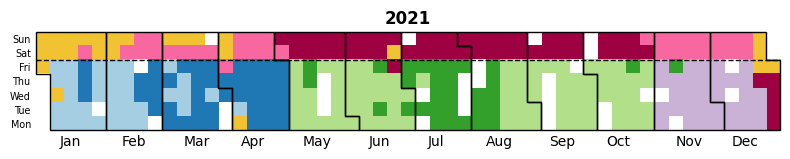

In [81]:
final_method, final_params = "gmm", dict(k=8)
cluster_labels = fit_clustering(final_method, vectorized_day_dataset_no_nans, **final_params)
n_clusters_t = len(np.unique(cluster_labels))
print("Final selected clustering: k-means, k =", n_clusters_t)

days_colors, color_to_cluster, style_to_cluster = assign_colors(n_clusters_t, days_not_nans, cluster_labels)
make_calendar_visualization_figure(days_not_nans, cluster_labels, n_clusters_t, [2021], days_colors,
                                    color_to_cluster, save_figure=None)

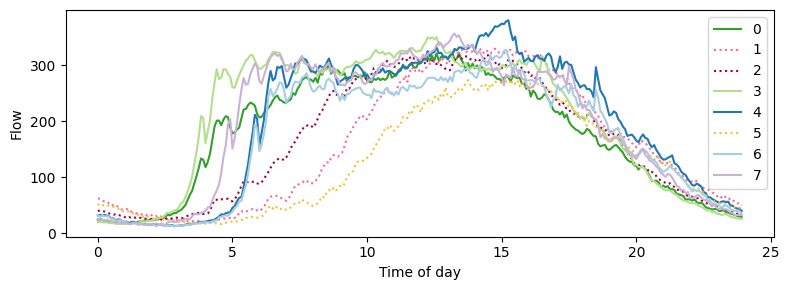

In [82]:
centroids_xx, centroids_yy_daytypes, cluster_ids = [], [], []
for i in range(n_clusters_t):
    centroids_xx.append(x_axis_hours)
    centroid_yy = list(np.nanmean(vectorized_day_dataset_no_nans[np.where(cluster_labels == i)[0], :], 0).transpose())
    centroids_yy_daytypes.append(centroid_yy)
    cluster_ids.append(i)

make_figure_centroids(centroids_xx, centroids_yy_daytypes, color_to_cluster, style_to_cluster, cluster_ids)